# Sistem Pendukung Keputusan IHSG untuk Tiga Klien

**Notebook Kaggle siap jalan**

Notebook ini memakai satu dataset OHLCV IHSG dan 15 indikator teknikal, tetapi
membentuk target, horizon, model, dan metrik yang berbeda untuk:

1. analis risiko;
2. trader harian; dan
3. manajer dana pensiun.

Desain utama:

- data dibagi secara kronologis;
- terdapat *purge gap* sesuai horizon target;
- parameter hanya dipilih memakai data validasi;
- data uji dibuka satu kali;
- transaksi trader memakai fitur penutupan hari ke-\(t\), lalu dieksekusi pada
  pembukaan hari ke-\(t+1\);
- biaya transaksi ikut dihitung;
- setiap tahap berakhir dengan tabel atau visualisasi.

> Catatan: notebook ini merupakan baseline penelitian. Hasilnya bukan saran
> investasi dan tidak menjamin keuntungan pada masa depan.



## A. Algoritma Program

**Masukan**

- OHLCV harian IHSG;
- periode data;
- horizon risiko 10 hari;
- horizon trader 1 hari;
- horizon dana pensiun 12 bulan;
- biaya transaksi dan tingkat bebas risiko.

**Proses umum**

1. Memuat data IHSG dari CSV Kaggle atau Yahoo Finance.
2. Memeriksa urutan tanggal, duplikasi, nilai hilang, dan konsistensi OHLC.
3. Membentuk 15 indikator teknikal hanya dari informasi masa lalu dan saat ini.
4. Membentuk tiga dataset target dari sumber data yang sama.
5. Membagi data menjadi latih, validasi, dan uji secara kronologis.
6. Menyisihkan *gap* sebesar horizon target untuk mencegah target bertumpang
   tindih pada batas periode.
7. Memilih konfigurasi memakai data validasi.
8. Melatih ulang model terpilih pada data latih dan validasi.
9. Menguji model sekali pada data uji.
10. Membandingkan hasil statistik, manfaat ekonomi, risiko, dan keterbatasan.

**Keluaran**

- tabel kualitas data;
- grafik harga dan volume;
- tabel indikator dan peta korelasi;
- hasil prediksi volatilitas dan VaR;
- hasil klasifikasi arah dan simulasi trader;
- hasil alokasi jangka panjang dana pensiun;
- matriks perbandingan tiga klien;
- tabel audit bug dan logika.



## B. Pseudocode Program

```text
MULAI
  TETAPKAN horizon, biaya transaksi, dan tingkat bebas risiko
  MUAT data OHLCV IHSG
  JIKA CSV Kaggle tersedia
      gunakan CSV yang memiliki kolom OHLCV
  JIKA TIDAK
      unduh ticker ^JKSE
  VALIDASI tanggal dan konsistensi OHLCV
  HITUNG 15 indikator teknikal tanpa data masa depan
  HAPUS baris warm-up indikator

  UNTUK analis risiko
      target = volatilitas return 10 hari mendatang
      pisahkan data secara kronologis dengan gap 10 hari
      latih model volatilitas
      hitung MAE, pelanggaran VaR, dan deteksi lonjakan risiko
      tampilkan tabel dan grafik

  UNTUK trader harian
      target = arah return pembukaan-ke-penutupan hari berikutnya
      pisahkan data secara kronologis dengan gap 1 hari
      latih klasifikasi logistik
      pilih ambang probabilitas pada validasi
      eksekusi pada pembukaan hari berikutnya
      kurangi biaya transaksi
      hitung balanced accuracy, F1, return bersih, dan profit factor
      tampilkan tabel, confusion matrix, dan kurva ekuitas

  UNTUK manajer dana pensiun
      ubah data menjadi frekuensi bulanan
      target = return kumulatif 12 bulan mendatang
      pisahkan data dengan gap 12 bulan
      pilih regularisasi model pada validasi
      bentuk bobot IHSG dan aset bebas risiko
      hitung return tahunan, Sharpe, drawdown, dan pencapaian kewajiban
      tampilkan tabel dan grafik

  JALANKAN audit kebocoran data, execution lag, split, dan fitur
  BANDINGKAN tiga formulasi masalah
  SIMPAN tabel hasil ke /kaggle/working
SELESAI
```



In [3]:
import os
import sys
import glob
import math
import warnings
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=["#12355B", "#00A6A6", "#F4A261", "#D1495B", "#6A4C93"],
)
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "figure.dpi": 120,
    }
)

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
START_DATE = "2005-01-01"
END_DATE = None
TICKER = "^JKSE"
LOCAL_CSV = ""  # Isi path CSV jika ingin memilih file tertentu.

RISK_HORIZON_DAYS = 10
TRADING_COST_BPS = 10
PENSION_HORIZON_MONTHS = 12
RISK_FREE_ANNUAL = 0.04
LIABILITY_TARGET_ANNUAL = 0.06

versions = pd.DataFrame(
    {
        "Komponen": ["Python", "NumPy", "pandas", "scikit-learn", "yfinance"],
        "Versi": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            __import__("sklearn").__version__,
            getattr(yf, "__version__", "tidak terdeteksi"),
        ],
    }
)
display(Markdown("### Output Tahap 1: Konfigurasi dan Versi"))
display(versions)



### Output Tahap 1: Konfigurasi dan Versi

,Komponen,Versi
0,Python,3.12.13
1,NumPy,2.0.2
2,pandas,2.3.3
3,scikit-learn,1.6.1
4,yfinance,0.2.66


**Analisis Tahap 1**

Versi paket dicatat untuk mendukung replikasi. Parameter horizon dan biaya
ditempatkan pada satu bagian agar perubahan skenario tidak tersebar di banyak
sel. Biaya 10 basis poin bersifat asumsi. Pengguna perlu menggantinya dengan
komisi, pajak, spread, dan slippage yang sesuai dengan instrumen yang benar-benar
diperdagangkan.



### Output Tahap 2: Data IHSG

,Sumber,Tanggal awal,Tanggal akhir,Jumlah observasi,Jumlah kolom
0,Yahoo Finance: ^JKSE,2005-01-03,2026-07-30,5226,5


,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03,"1,000.5540","1,002.3720",994.5310,"1,000.8770",4584400
2005-01-04,"1,002.2720","1,019.0710","1,002.2720","1,018.5430",16504000
2005-01-05,"1,016.4060","1,025.3831","1,013.3660","1,015.4310",22712700


,Open,High,Low,Close,Volume
Date,,,,,
2026-07-28,"6,175.1982","6,199.4399","6,130.5879","6,130.5879",198014300
2026-07-29,"6,141.1621","6,174.4131","6,029.3242","6,091.3862",288519700
2026-07-30,"6,110.2832","6,186.3628","6,106.5459","6,186.3628",0


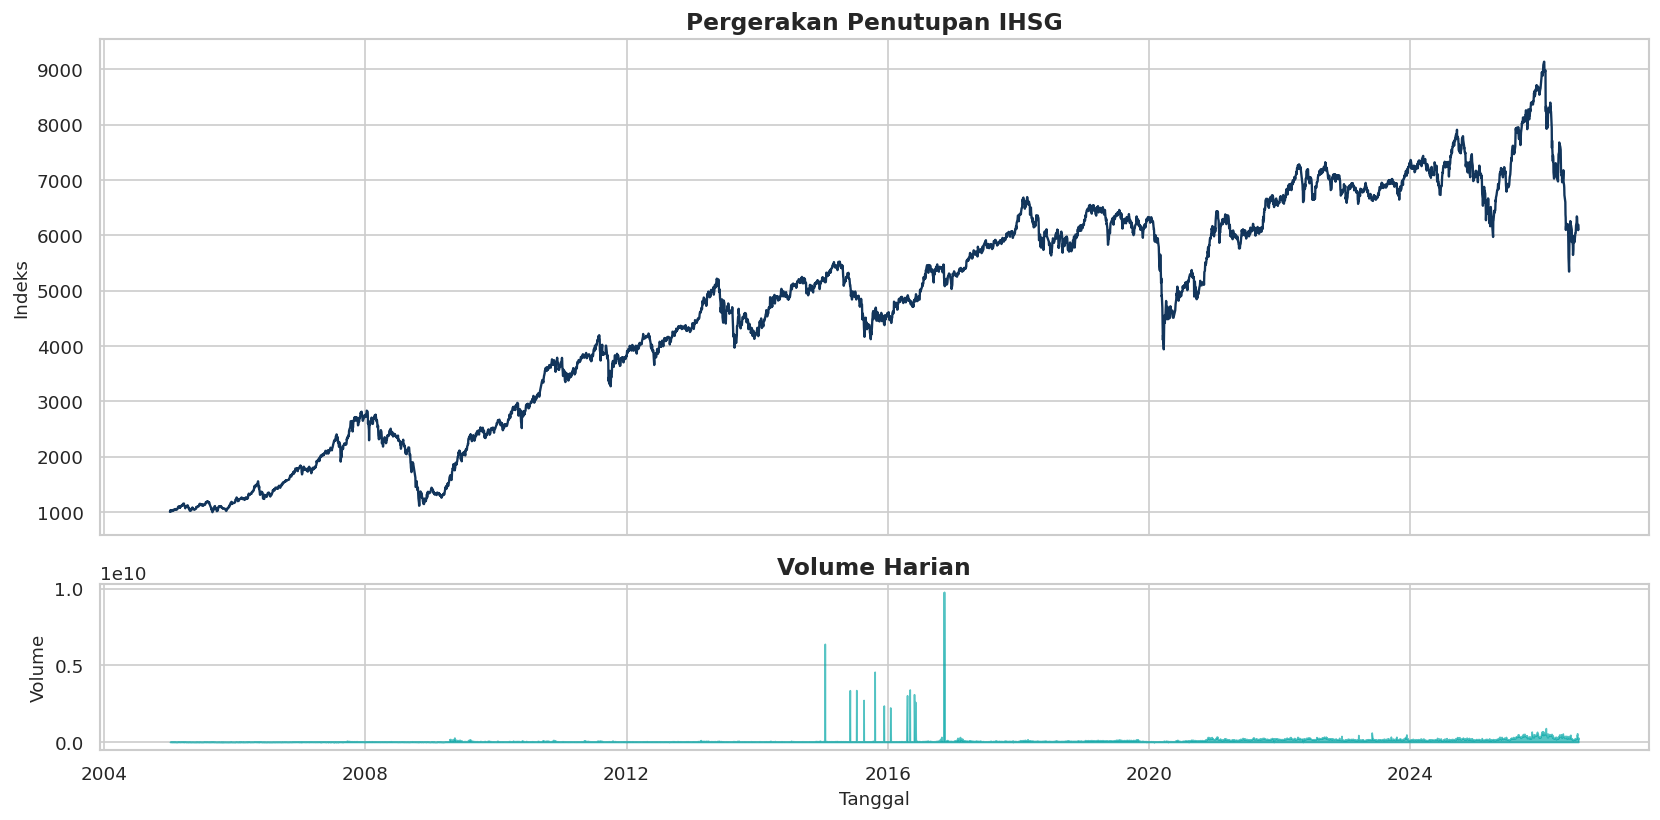

In [4]:
def canonicalize_ohlcv(raw: pd.DataFrame) -> pd.DataFrame:
    """Menyeragamkan keluaran CSV atau yfinance menjadi Date-indexed OHLCV."""
    data = raw.copy()

    if isinstance(data.columns, pd.MultiIndex):
        # yfinance satu ticker biasanya memakai level harga dan ticker.
        if len(data.columns.get_level_values(-1).unique()) == 1:
            data.columns = data.columns.get_level_values(0)
        else:
            data = data.xs(data.columns.get_level_values(-1)[0], axis=1, level=-1)

    data.columns = [
        str(c).strip().lower().replace(" ", "_").replace(".", "_") for c in data.columns
    ]

    if "date" in data.columns:
        data["date"] = pd.to_datetime(data["date"], errors="coerce")
        data = data.set_index("date")
    elif "tanggal" in data.columns:
        data["tanggal"] = pd.to_datetime(data["tanggal"], errors="coerce")
        data = data.set_index("tanggal")
    else:
        data.index = pd.to_datetime(data.index, errors="coerce")

    aliases = {
        "open": ["open", "pembukaan"],
        "high": ["high", "tertinggi"],
        "low": ["low", "terendah"],
        "close": ["close", "penutupan", "adj_close", "adjusted_close"],
        "volume": ["volume", "vol"],
    }

    selected = {}
    for target, candidates in aliases.items():
        found = next((c for c in candidates if c in data.columns), None)
        if found is not None:
            selected[target.title()] = pd.to_numeric(data[found], errors="coerce")

    missing = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c not in selected]
    if missing:
        raise ValueError(f"Kolom OHLCV belum lengkap. Kolom yang hilang: {missing}")

    data = pd.DataFrame(selected)
    data = data[~data.index.isna()].sort_index()
    data = data[~data.index.duplicated(keep="last")]
    data.index.name = "Date"
    return data


def find_valid_kaggle_csv() -> str | None:
    """Memilih CSV pertama yang benar-benar memiliki struktur OHLCV."""
    candidates = []
    if LOCAL_CSV:
        candidates.append(LOCAL_CSV)
    candidates.extend(sorted(glob.glob("/kaggle/input/**/*.csv", recursive=True)))

    for path in candidates:
        try:
            preview = pd.read_csv(path, nrows=8)
            cols = {str(c).strip().lower().replace(" ", "_") for c in preview.columns}
            has_date = bool({"date", "tanggal"} & cols)
            has_prices = {"open", "high", "low", "close"}.issubset(cols)
            has_adjusted = {"open", "high", "low", "adj_close"}.issubset(cols)
            if has_date and (has_prices or has_adjusted) and "volume" in cols:
                return path
        except Exception:
            continue
    return None


csv_path = find_valid_kaggle_csv()
if csv_path:
    raw_df = pd.read_csv(csv_path)
    df = canonicalize_ohlcv(raw_df)
    data_source = f"CSV Kaggle: {csv_path}"
else:
    raw_df = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
        threads=False,
        timeout=30,
    )
    if raw_df.empty:
        raise RuntimeError(
            "Data IHSG gagal dimuat. Aktifkan Internet pada Kaggle atau lampirkan "
            "CSV dengan kolom Date, Open, High, Low, Close, dan Volume."
        )
    df = canonicalize_ohlcv(raw_df)
    data_source = f"Yahoo Finance: {TICKER}"

if len(df) < 1000:
    raise ValueError(
        f"Observasi hanya {len(df)}. Gunakan data lebih panjang agar tiga horizon dapat diuji."
    )

display(Markdown("### Output Tahap 2: Data IHSG"))
summary_data = pd.DataFrame(
    {
        "Sumber": [data_source],
        "Tanggal awal": [df.index.min().date()],
        "Tanggal akhir": [df.index.max().date()],
        "Jumlah observasi": [len(df)],
        "Jumlah kolom": [df.shape[1]],
    }
)
display(summary_data)
display(df.head(3))
display(df.tail(3))

fig, axes = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
axes[0].plot(df.index, df["Close"], color="#12355B", linewidth=1.4)
axes[0].set_title("Pergerakan Penutupan IHSG")
axes[0].set_ylabel("Indeks")
axes[1].fill_between(df.index, df["Volume"], color="#00A6A6", alpha=0.65)
axes[1].set_title("Volume Harian")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Tanggal")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_data_ihsg.png", bbox_inches="tight")
plt.show()



**Analisis Tahap 2**

Program mengutamakan CSV yang dilampirkan pada Kaggle. Jika tidak tersedia,
program mengunduh `^JKSE`. Sumber Yahoo Finance cocok untuk demonstrasi, tetapi
bukan sumber resmi Bursa Efek Indonesia. Penelitian final perlu mencatat sumber,
zona waktu, penyesuaian harga, hari libur bursa, serta kualitas volume. Grafik
awal dipakai untuk mendeteksi periode kosong, perubahan skala, dan lonjakan yang
perlu diperiksa sebelum pemodelan.



### Output Tahap 3: Audit Kualitas Data

,Pemeriksaan,Hasil
0,Tanggal terurut naik,True
1,Tanggal duplikat,0
2,Nilai hilang total,0
3,Harga nonpositif,0
4,High di bawah Open/Close,0
5,Low di atas Open/Close,0
6,Volume nol atau hilang (%),0.1722


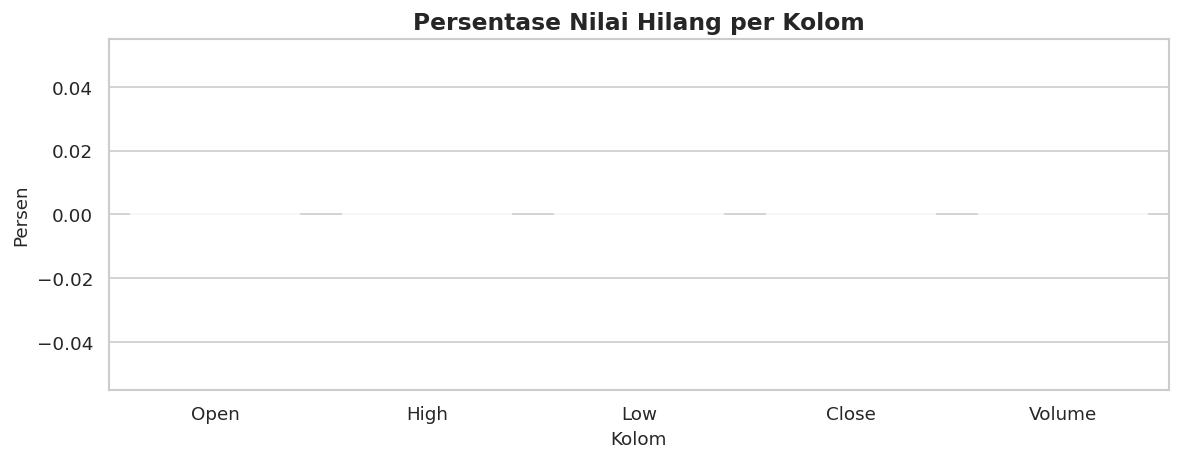

In [5]:
def ohlcv_quality_report(data: pd.DataFrame) -> pd.DataFrame:
    checks = {
        "Tanggal terurut naik": data.index.is_monotonic_increasing,
        "Tanggal duplikat": int(data.index.duplicated().sum()),
        "Nilai hilang total": int(data.isna().sum().sum()),
        "Harga nonpositif": int((data[["Open", "High", "Low", "Close"]] <= 0).sum().sum()),
        "High di bawah Open/Close": int(
            (
                data["High"]
                < data[["Open", "Close"]].max(axis=1)
            ).sum()
        ),
        "Low di atas Open/Close": int(
            (
                data["Low"]
                > data[["Open", "Close"]].min(axis=1)
            ).sum()
        ),
        "Volume nol atau hilang (%)": float(
            ((data["Volume"].fillna(0) <= 0).mean()) * 100
        ),
    }
    return pd.DataFrame({"Pemeriksaan": checks.keys(), "Hasil": checks.values()})


quality = ohlcv_quality_report(df)
display(Markdown("### Output Tahap 3: Audit Kualitas Data"))
display(quality)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color="#D1495B", ax=ax)
ax.set_title("Persentase Nilai Hilang per Kolom")
ax.set_ylabel("Persen")
ax.set_xlabel("Kolom")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_kualitas_data.png", bbox_inches="tight")
plt.show()

# Hanya koreksi yang dapat dipertanggungjawabkan.
df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")

invalid_ohlc = (
    (df["High"] < df[["Open", "Close"]].max(axis=1))
    | (df["Low"] > df[["Open", "Close"]].min(axis=1))
)
if invalid_ohlc.any():
    raise ValueError(
        f"Ditemukan {invalid_ohlc.sum()} baris OHLC tidak konsisten. "
        "Periksa sumber data, jangan memperbaiki harga secara otomatis."
    )



**Analisis Tahap 3**

Program menghentikan proses jika hubungan OHLC tidak logis. Mengubah harga
secara otomatis dapat menutupi kesalahan sumber. Nilai volume nol tidak langsung
dihapus karena indeks pasar kadang memiliki data volume yang tidak konsisten
antarpenyedia. Kondisi tersebut dicatat dan fitur MFI dinetralkan jika volume
tidak cukup andal.



### Output Tahap 4: Lima Belas Indikator Teknikal

,No.,Fitur,Nilai terakhir
0,1,sma_ratio_20,0.0150
1,2,ema_ratio_20,0.0101
2,3,wma_ratio_20,0.0048
3,4,rsi_14,53.6513
4,5,roc_10,0.0128
5,6,stoch_k_14,51.8223
6,7,stoch_d_3,45.0290
7,8,macd_pct,0.0057
8,9,macd_signal_pct,0.0038
9,10,cci_20,36.5069


,Indikator,Nilai
0,Keandalan volume,Memadai
1,Baris setelah warm-up,5202
2,Warm-up terbuang,24


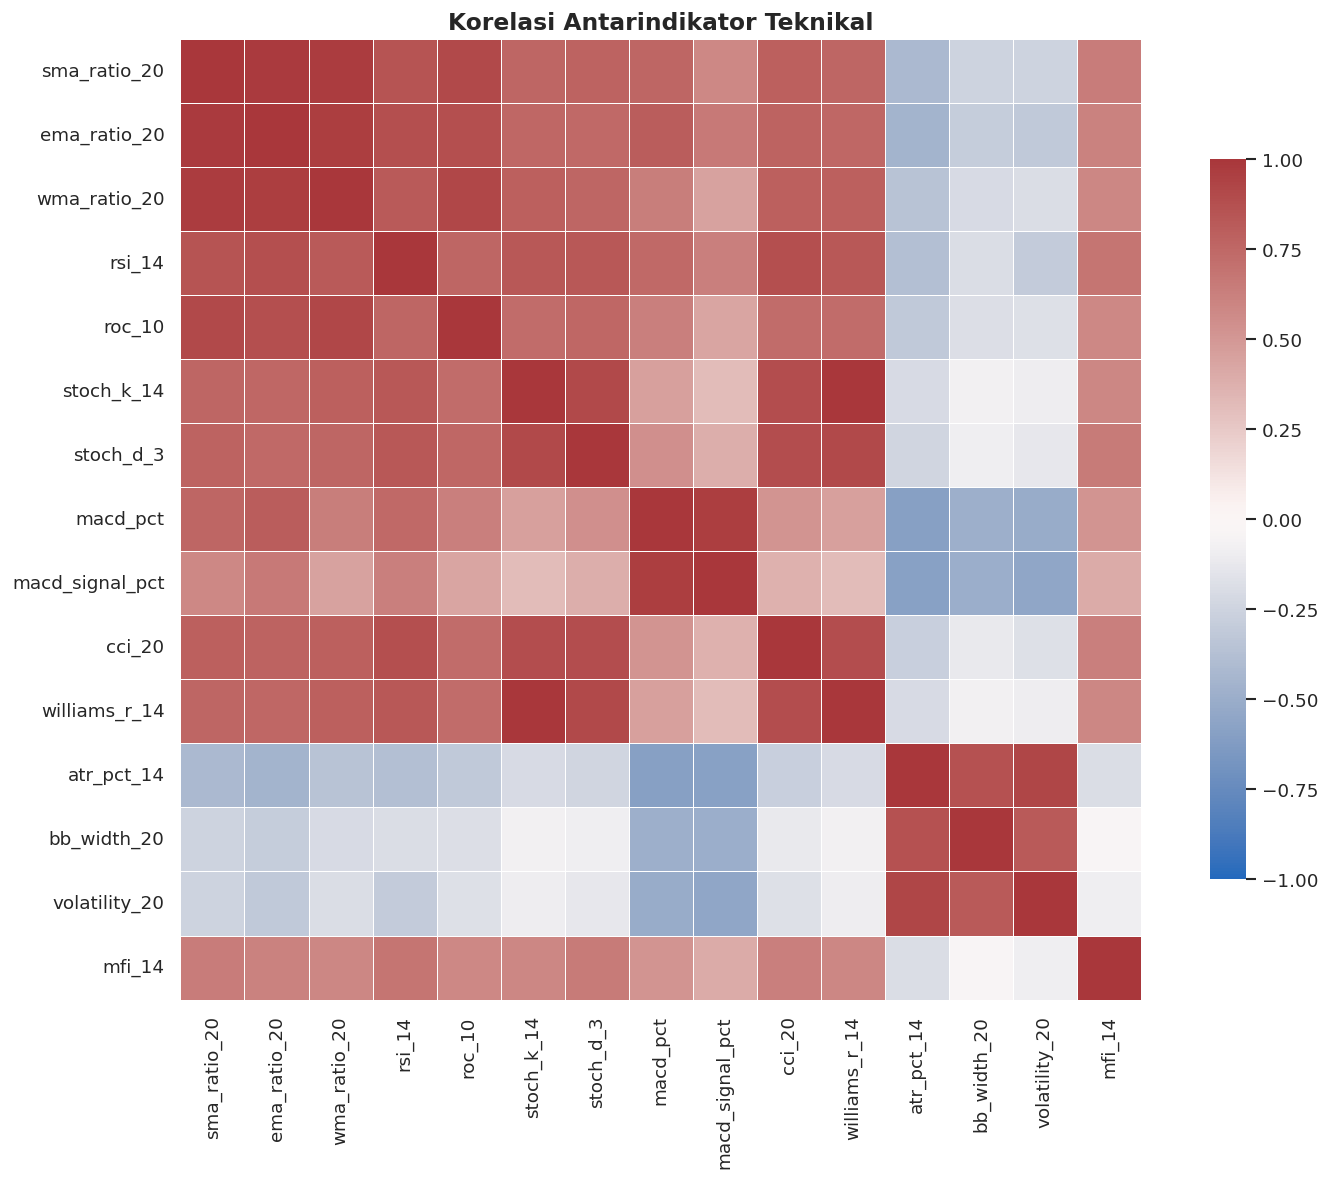

In [6]:
def safe_divide(a: pd.Series, b: pd.Series) -> pd.Series:
    return a / b.replace(0, np.nan)


def future_rolling(series: pd.Series, horizon: int, operation: str) -> pd.Series:
    """Agregasi t+1 sampai t+h, lalu diletakkan pada baris t."""
    shifted = series.shift(-1)
    roller = shifted.rolling(horizon, min_periods=horizon)
    if operation == "mean":
        result = roller.mean()
    elif operation == "sum":
        result = roller.sum()
    else:
        raise ValueError("operation harus 'mean' atau 'sum'")
    return result.shift(-(horizon - 1))


def build_technical_features(data: pd.DataFrame):
    out = data.copy()
    close, high, low, volume = (
        out["Close"],
        out["High"],
        out["Low"],
        out["Volume"],
    )

    log_return = np.log(close / close.shift(1))
    out["log_return"] = log_return

    sma20 = close.rolling(20).mean()
    ema20 = close.ewm(span=20, adjust=False).mean()
    weights = np.arange(1, 21)
    wma20 = close.rolling(20).apply(
        lambda x: np.dot(x, weights) / weights.sum(), raw=True
    )

    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    rs = safe_divide(gain, loss)
    rsi14 = 100 - (100 / (1 + rs))

    low14 = low.rolling(14).min()
    high14 = high.rolling(14).max()
    stoch_k = 100 * safe_divide(close - low14, high14 - low14)

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()

    typical = (high + low + close) / 3
    typical_sma = typical.rolling(20).mean()
    mean_dev = typical.rolling(20).apply(
        lambda x: np.mean(np.abs(x - np.mean(x))), raw=True
    )
    cci20 = safe_divide(typical - typical_sma, 0.015 * mean_dev)

    prev_close = close.shift(1)
    true_range = pd.concat(
        [(high - low), (high - prev_close).abs(), (low - prev_close).abs()],
        axis=1,
    ).max(axis=1)
    atr14 = true_range.rolling(14).mean()

    std20 = close.rolling(20).std()
    upper_bb = sma20 + 2 * std20
    lower_bb = sma20 - 2 * std20

    volume_reliable = (volume.fillna(0) > 0).mean() >= 0.80
    if volume_reliable:
        money_flow = typical * volume
        positive_flow = money_flow.where(typical.diff() > 0, 0.0)
        negative_flow = money_flow.where(typical.diff() < 0, 0.0)
        money_ratio = safe_divide(
            positive_flow.rolling(14).sum(),
            negative_flow.rolling(14).sum(),
        )
        mfi14 = 100 - (100 / (1 + money_ratio))
    else:
        mfi14 = pd.Series(50.0, index=out.index)

    features = pd.DataFrame(index=out.index)
    features["sma_ratio_20"] = safe_divide(close, sma20) - 1
    features["ema_ratio_20"] = safe_divide(close, ema20) - 1
    features["wma_ratio_20"] = safe_divide(close, wma20) - 1
    features["rsi_14"] = rsi14
    features["roc_10"] = close.pct_change(10)
    features["stoch_k_14"] = stoch_k
    features["stoch_d_3"] = stoch_k.rolling(3).mean()
    features["macd_pct"] = safe_divide(macd, close)
    features["macd_signal_pct"] = safe_divide(macd_signal, close)
    features["cci_20"] = cci20
    features["williams_r_14"] = -100 * safe_divide(high14 - close, high14 - low14)
    features["atr_pct_14"] = safe_divide(atr14, close)
    features["bb_width_20"] = safe_divide(upper_bb - lower_bb, sma20)
    features["volatility_20"] = log_return.rolling(20).std() * np.sqrt(252)
    features["mfi_14"] = mfi14

    features = features.replace([np.inf, -np.inf], np.nan)
    return out, features, volume_reliable


market, features, volume_reliable = build_technical_features(df)
FEATURE_COLUMNS = features.columns.tolist()

if len(FEATURE_COLUMNS) != 15:
    raise AssertionError(f"Jumlah indikator harus 15, bukan {len(FEATURE_COLUMNS)}")

model_base = market.join(features).dropna(subset=FEATURE_COLUMNS).copy()

display(Markdown("### Output Tahap 4: Lima Belas Indikator Teknikal"))
feature_dictionary = pd.DataFrame(
    {
        "No.": range(1, 16),
        "Fitur": FEATURE_COLUMNS,
        "Nilai terakhir": model_base[FEATURE_COLUMNS].iloc[-1].values,
    }
)
display(feature_dictionary)
display(
    pd.DataFrame(
        {
            "Indikator": ["Keandalan volume", "Baris setelah warm-up", "Warm-up terbuang"],
            "Nilai": [
                "Memadai" if volume_reliable else "Tidak memadai, MFI dinetralkan ke 50",
                len(model_base),
                len(df) - len(model_base),
            ],
        }
    )
)

fig, ax = plt.subplots(figsize=(13, 10))
corr = model_base[FEATURE_COLUMNS].corr()
sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Korelasi Antarindikator Teknikal")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_korelasi_fitur.png", bbox_inches="tight")
plt.show()



**Analisis Tahap 4**

Fitur rasio digunakan untuk mengurangi ketergantungan pada level absolut IHSG.
Peta korelasi membantu mendeteksi redundansi. SMA, EMA, dan WMA dapat bergerak
sangat mirip. Redundansi tidak selalu merusak model berbasis pohon, tetapi dapat
membuat koefisien model linear kurang stabil. Standardisasi dan regularisasi
digunakan pada model linear. Fitur pada baris ke-\(t\) hanya memakai data sampai
penutupan hari ke-\(t\).



In [7]:
def purged_chronological_split(
    data: pd.DataFrame,
    gap: int,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    min_size: int = 30,
):
    """Split 70/15/15 dengan purge gap pada dua batas keputusan."""
    n = len(data)
    train_boundary = int(n * train_fraction)
    validation_boundary = int(n * (train_fraction + validation_fraction))

    train = data.iloc[: max(0, train_boundary - gap)].copy()
    validation = data.iloc[train_boundary : max(train_boundary, validation_boundary - gap)].copy()
    test = data.iloc[validation_boundary:].copy()

    if min(len(train), len(validation), len(test)) < min_size:
        raise ValueError(
            f"Split terlalu kecil: train={len(train)}, validasi={len(validation)}, "
            f"uji={len(test)}. Perpanjang periode data atau pendekkan horizon."
        )
    if not (train.index.max() < validation.index.min() < test.index.min()):
        raise AssertionError("Urutan split kronologis tidak valid.")
    return train, validation, test


def split_summary(name: str, train, validation, test, gap: int):
    return pd.DataFrame(
        {
            "Klien": [name] * 3,
            "Bagian": ["Latih", "Validasi", "Uji"],
            "Awal": [x.index.min().date() for x in [train, validation, test]],
            "Akhir": [x.index.max().date() for x in [train, validation, test]],
            "Observasi": [len(x) for x in [train, validation, test]],
            "Purge gap": [gap] * 3,
        }
    )


display(Markdown("### Output Tahap 5: Fungsi Pembagian Kronologis"))
display(
    pd.DataFrame(
        {
            "Prinsip": [
                "Data tidak diacak",
                "Gap mengikuti horizon",
                "Validasi memilih model",
                "Uji dibuka sekali",
            ],
            "Tujuan": [
                "Meniru aliran waktu nyata",
                "Mencegah target lintas batas bertumpang tindih",
                "Mencegah pemilihan berdasarkan data uji",
                "Menjaga estimasi generalisasi",
            ],
        }
    )
)



### Output Tahap 5: Fungsi Pembagian Kronologis

,Prinsip,Tujuan
0,Data tidak diacak,Meniru aliran waktu nyata
1,Gap mengikuti horizon,Mencegah target lintas batas bertumpang tindih
2,Validasi memilih model,Mencegah pemilihan berdasarkan data uji
3,Uji dibuka sekali,Menjaga estimasi generalisasi


## C. Model 1: Analis Risiko

Target risiko adalah volatilitas tahunan yang dihitung dari return 10 hari
perdagangan mendatang:

\[
\sigma_{t,10}=\sqrt{252\times\frac{1}{10}
\sum_{i=1}^{10}r_{t+i}^{2}}
\]

VaR parametrik 95 persen untuk horizon 10 hari dihitung dari prediksi
volatilitas. Evaluasi mencakup MAE volatilitas, selisih tingkat pelanggaran VaR
terhadap 5 persen, dan recall lonjakan risiko.



### Output Tahap 6: Dataset Risiko

,Klien,Bagian,Awal,Akhir,Observasi,Purge gap
0,Analis risiko,Latih,2005-02-01,2019-12-30,3624,10
1,Analis risiko,Validasi,2020-01-16,2023-03-03,769,10
2,Analis risiko,Uji,2023-03-20,2026-07-16,779,10


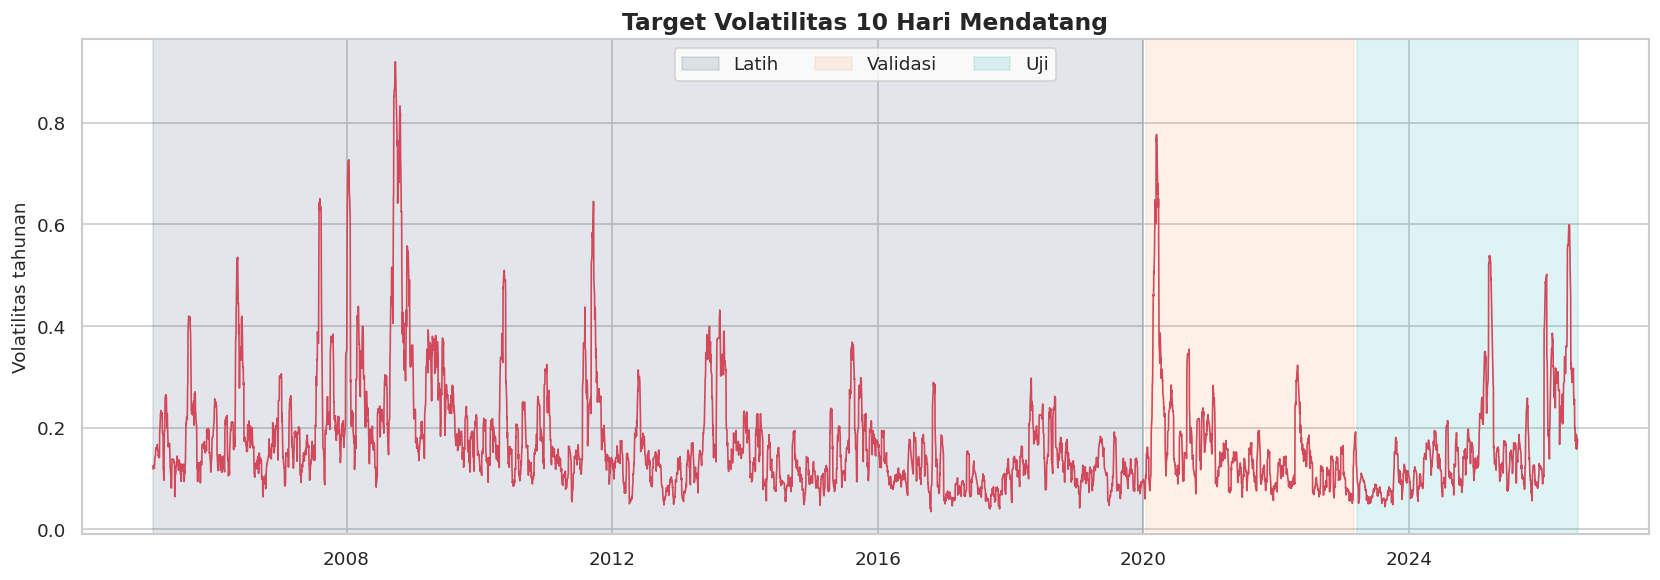

In [8]:
risk_data = model_base.copy()
risk_data["risk_target_vol"] = np.sqrt(
    252
    * future_rolling(risk_data["log_return"] ** 2, RISK_HORIZON_DAYS, "mean")
)
risk_data["future_log_return_h"] = future_rolling(
    risk_data["log_return"], RISK_HORIZON_DAYS, "sum"
)
risk_data = risk_data.dropna(
    subset=FEATURE_COLUMNS + ["risk_target_vol", "future_log_return_h"]
)

risk_train, risk_val, risk_test = purged_chronological_split(
    risk_data, gap=RISK_HORIZON_DAYS
)

display(Markdown("### Output Tahap 6: Dataset Risiko"))
display(split_summary("Analis risiko", risk_train, risk_val, risk_test, RISK_HORIZON_DAYS))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(risk_data.index, risk_data["risk_target_vol"], color="#D1495B", linewidth=1)
ax.axvspan(risk_train.index.min(), risk_train.index.max(), alpha=0.12, color="#12355B", label="Latih")
ax.axvspan(risk_val.index.min(), risk_val.index.max(), alpha=0.15, color="#F4A261", label="Validasi")
ax.axvspan(risk_test.index.min(), risk_test.index.max(), alpha=0.13, color="#00A6A6", label="Uji")
ax.set_title(f"Target Volatilitas {RISK_HORIZON_DAYS} Hari Mendatang")
ax.set_ylabel("Volatilitas tahunan")
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_target_risiko.png", bbox_inches="tight")
plt.show()



In [9]:
risk_candidates = [
    {"learning_rate": 0.03, "max_leaf_nodes": 15, "l2_regularization": 0.5},
    {"learning_rate": 0.05, "max_leaf_nodes": 15, "l2_regularization": 1.0},
    {"learning_rate": 0.05, "max_leaf_nodes": 31, "l2_regularization": 1.0},
]

risk_validation_rows = []
for i, params in enumerate(risk_candidates, start=1):
    model = HistGradientBoostingRegressor(
        loss="absolute_error",
        max_iter=300,
        random_state=RANDOM_STATE,
        **params,
    )
    model.fit(risk_train[FEATURE_COLUMNS], risk_train["risk_target_vol"])
    val_pred = np.clip(model.predict(risk_val[FEATURE_COLUMNS]), 1e-6, None)
    risk_validation_rows.append(
        {
            "Konfigurasi": f"R{i}",
            **params,
            "MAE validasi": mean_absolute_error(risk_val["risk_target_vol"], val_pred),
        }
    )

risk_validation = pd.DataFrame(risk_validation_rows).sort_values("MAE validasi")
best_risk_id = int(risk_validation.iloc[0]["Konfigurasi"][1:]) - 1
best_risk_params = risk_candidates[best_risk_id]

display(Markdown("### Output Tahap 7: Seleksi Model Risiko"))
display(risk_validation)



### Output Tahap 7: Seleksi Model Risiko

,Konfigurasi,learning_rate,max_leaf_nodes,l2_regularization,MAE validasi
0,R1,0.0300,15,0.5000,0.0484
1,R2,0.0500,15,1.0000,0.0502
2,R3,0.0500,31,1.0000,0.0521


### Output Tahap 8: Evaluasi Analis Risiko

,Model,MAE volatilitas,Pelanggaran VaR (%),Error cakupan VaR,Recall lonjakan risiko
0,HistGradientBoosting,0.0519,8.9859,0.0399,0.3291
1,Naif: volatilitas 20 hari,0.0611,8.0873,0.0309,NaN


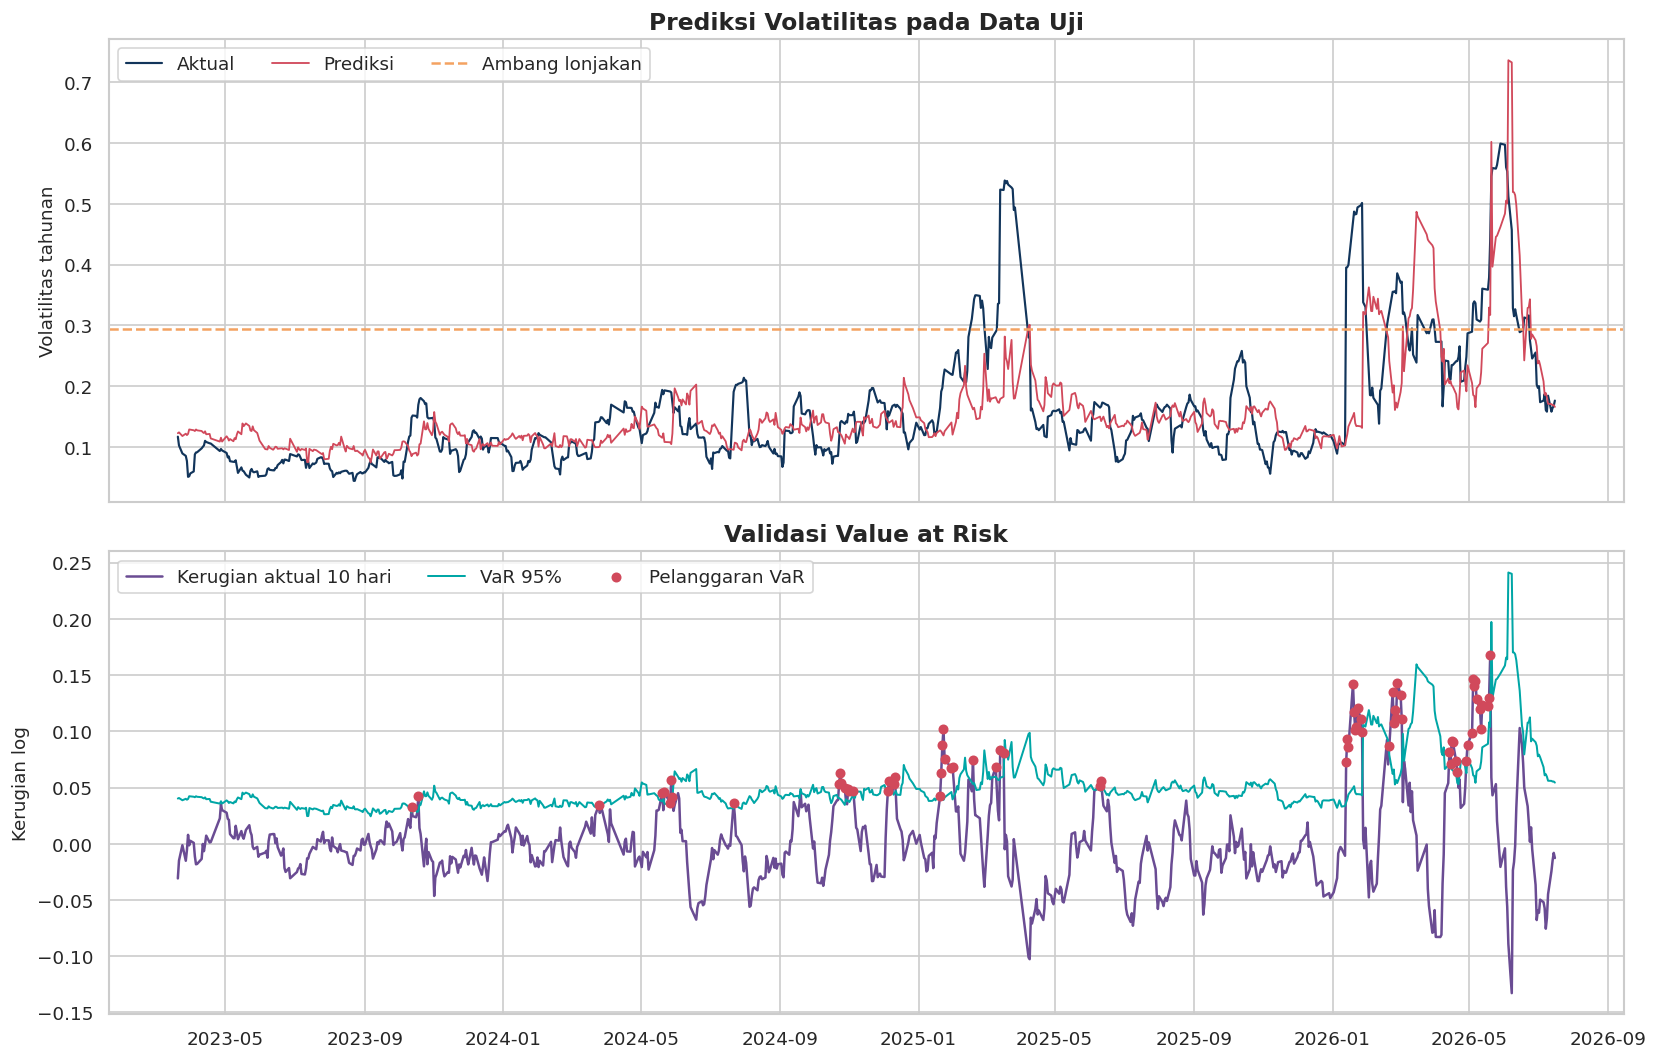

In [10]:
risk_fit = pd.concat([risk_train, risk_val]).sort_index()
risk_model = HistGradientBoostingRegressor(
    loss="absolute_error",
    max_iter=300,
    random_state=RANDOM_STATE,
    **best_risk_params,
)
risk_model.fit(risk_fit[FEATURE_COLUMNS], risk_fit["risk_target_vol"])
risk_pred = np.clip(risk_model.predict(risk_test[FEATURE_COLUMNS]), 1e-6, None)

z_95 = 1.6448536269514722
var_95 = z_95 * (risk_pred / np.sqrt(252)) * np.sqrt(RISK_HORIZON_DAYS)
var_exception = risk_test["future_log_return_h"].values < -var_95

spike_threshold = risk_fit["risk_target_vol"].quantile(0.90)
actual_spike = risk_test["risk_target_vol"].values >= spike_threshold
predicted_spike = risk_pred >= spike_threshold
spike_recall = (
    (actual_spike & predicted_spike).sum() / actual_spike.sum()
    if actual_spike.sum() > 0
    else np.nan
)

naive_risk_pred = risk_test["volatility_20"].values
risk_metrics = pd.DataFrame(
    {
        "Model": ["HistGradientBoosting", "Naif: volatilitas 20 hari"],
        "MAE volatilitas": [
            mean_absolute_error(risk_test["risk_target_vol"], risk_pred),
            mean_absolute_error(risk_test["risk_target_vol"], naive_risk_pred),
        ],
        "Pelanggaran VaR (%)": [
            var_exception.mean() * 100,
            (
                risk_test["future_log_return_h"].values
                < -z_95
                * (naive_risk_pred / np.sqrt(252))
                * np.sqrt(RISK_HORIZON_DAYS)
            ).mean()
            * 100,
        ],
        "Error cakupan VaR": [
            abs(var_exception.mean() - 0.05),
            abs(
                (
                    risk_test["future_log_return_h"].values
                    < -z_95
                    * (naive_risk_pred / np.sqrt(252))
                    * np.sqrt(RISK_HORIZON_DAYS)
                ).mean()
                - 0.05
            ),
        ],
        "Recall lonjakan risiko": [spike_recall, np.nan],
    }
)

display(Markdown("### Output Tahap 8: Evaluasi Analis Risiko"))
display(risk_metrics)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(risk_test.index, risk_test["risk_target_vol"], color="#12355B", label="Aktual", linewidth=1.3)
axes[0].plot(risk_test.index, risk_pred, color="#D1495B", label="Prediksi", linewidth=1.1)
axes[0].axhline(spike_threshold, color="#F4A261", linestyle="--", label="Ambang lonjakan")
axes[0].set_title("Prediksi Volatilitas pada Data Uji")
axes[0].set_ylabel("Volatilitas tahunan")
axes[0].legend(ncol=3)

loss_h = -risk_test["future_log_return_h"].values
axes[1].plot(risk_test.index, loss_h, color="#6A4C93", label="Kerugian aktual 10 hari")
axes[1].plot(risk_test.index, var_95, color="#00A6A6", label="VaR 95%", linewidth=1.2)
axes[1].scatter(
    risk_test.index[var_exception],
    loss_h[var_exception],
    color="#D1495B",
    s=25,
    label="Pelanggaran VaR",
    zorder=4,
)
axes[1].set_title("Validasi Value at Risk")
axes[1].set_ylabel("Kerugian log")
axes[1].legend(ncol=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_hasil_risiko.png", bbox_inches="tight")
plt.show()



**Analisis Kritis Model Risiko**

MAE yang kecil belum cukup. Model dapat memiliki rata-rata galat rendah tetapi
terlambat mengenali lonjakan. Karena itu, recall lonjakan dan pelanggaran VaR
diperiksa terpisah. Tingkat pelanggaran ideal VaR 95 persen mendekati 5 persen,
bukan nol. Pelanggaran nol dapat menunjukkan VaR terlalu konservatif. Jika model
tidak mengungguli volatilitas bergulir sederhana, kompleksitas tambahan belum
memiliki dasar empiris.



## D. Model 2: Trader Harian

Target trader diselaraskan dengan waktu eksekusi:

\[
r^{exec}_{t+1}=\ln\left(\frac{Close_{t+1}}{Open_{t+1}}\right)
\]

Fitur dihitung setelah penutupan hari ke-\(t\). Posisi dibuka pada pembukaan
hari ke-\(t+1\). Aturan ini mencegah penggunaan harga yang telah berlalu.



### Output Tahap 9: Dataset Trader

,Klien,Bagian,Awal,Akhir,Observasi,Purge gap
0,Trader harian,Latih,2005-02-01,2020-01-22,3639,1
1,Trader harian,Validasi,2020-01-24,2023-03-29,779,1
2,Trader harian,Uji,2023-03-31,2026-07-29,781,1


,Periode,Hari naik (%),Hari turun/tetap (%)
0,Latih,54.2182,45.7818
1,Validasi,49.5507,50.4493
2,Uji,47.3752,52.6248


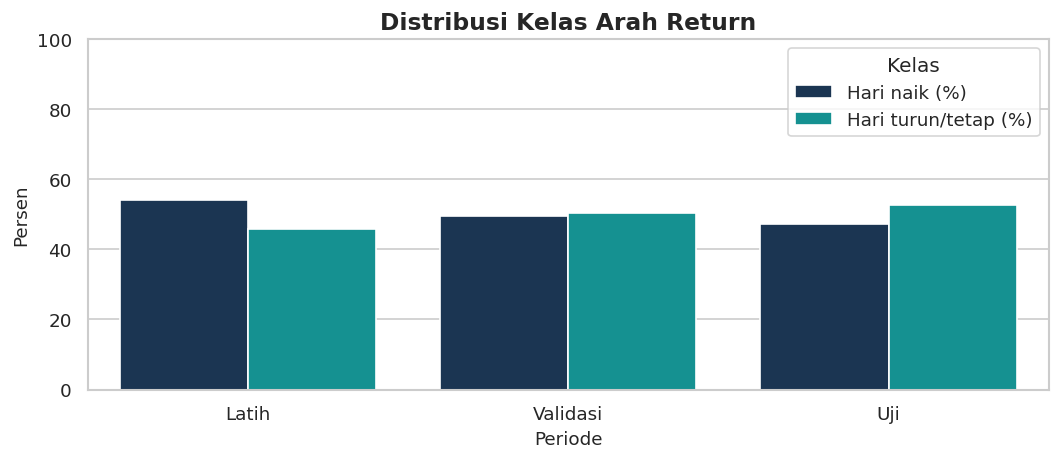

In [11]:
trader_data = model_base.copy()
trader_data["exec_return_next"] = np.log(
    trader_data["Close"].shift(-1) / trader_data["Open"].shift(-1)
)
trader_data["direction_next"] = (trader_data["exec_return_next"] > 0).astype(float)
trader_data = trader_data.dropna(subset=FEATURE_COLUMNS + ["exec_return_next"])
trader_data["direction_next"] = trader_data["direction_next"].astype(int)

trader_train, trader_val, trader_test = purged_chronological_split(
    trader_data, gap=1
)

display(Markdown("### Output Tahap 9: Dataset Trader"))
display(split_summary("Trader harian", trader_train, trader_val, trader_test, 1))
class_balance = pd.DataFrame(
    {
        "Periode": ["Latih", "Validasi", "Uji"],
        "Hari naik (%)": [
            trader_train["direction_next"].mean() * 100,
            trader_val["direction_next"].mean() * 100,
            trader_test["direction_next"].mean() * 100,
        ],
        "Hari turun/tetap (%)": [
            (1 - trader_train["direction_next"].mean()) * 100,
            (1 - trader_val["direction_next"].mean()) * 100,
            (1 - trader_test["direction_next"].mean()) * 100,
        ],
    }
)
display(class_balance)

fig, ax = plt.subplots(figsize=(9, 4))
class_long = class_balance.melt(
    id_vars="Periode",
    var_name="Kelas",
    value_name="Persen",
)
sns.barplot(data=class_long, x="Periode", y="Persen", hue="Kelas", ax=ax)
ax.set_title("Distribusi Kelas Arah Return")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_kelas_trader.png", bbox_inches="tight")
plt.show()



### Output Tahap 10: Seleksi Ambang Trader

,Ambang,Balanced accuracy,F1,Return bersih,Profit factor,Jumlah transaksi
0,0.4500,0.5032,0.6480,-0.3952,0.8227,71
1,0.4700,0.4853,0.5990,-0.4312,0.7783,149
2,0.4900,0.4666,0.5000,-0.4653,0.6930,203
3,0.5100,0.4813,0.3866,-0.3040,0.7191,155
4,0.5300,0.4836,0.2337,-0.2860,0.5361,124
5,0.5500,0.4877,0.0791,-0.1413,0.4779,54
6,0.5700,0.4912,0.0200,-0.0539,0.5954,20
7,0.5900,0.4975,0.0102,0.0139,1.2846,8
8,0.6100,0.4975,0.0051,-0.0160,0.5401,8
9,0.6300,0.5013,0.0052,0.0181,18.9196,2


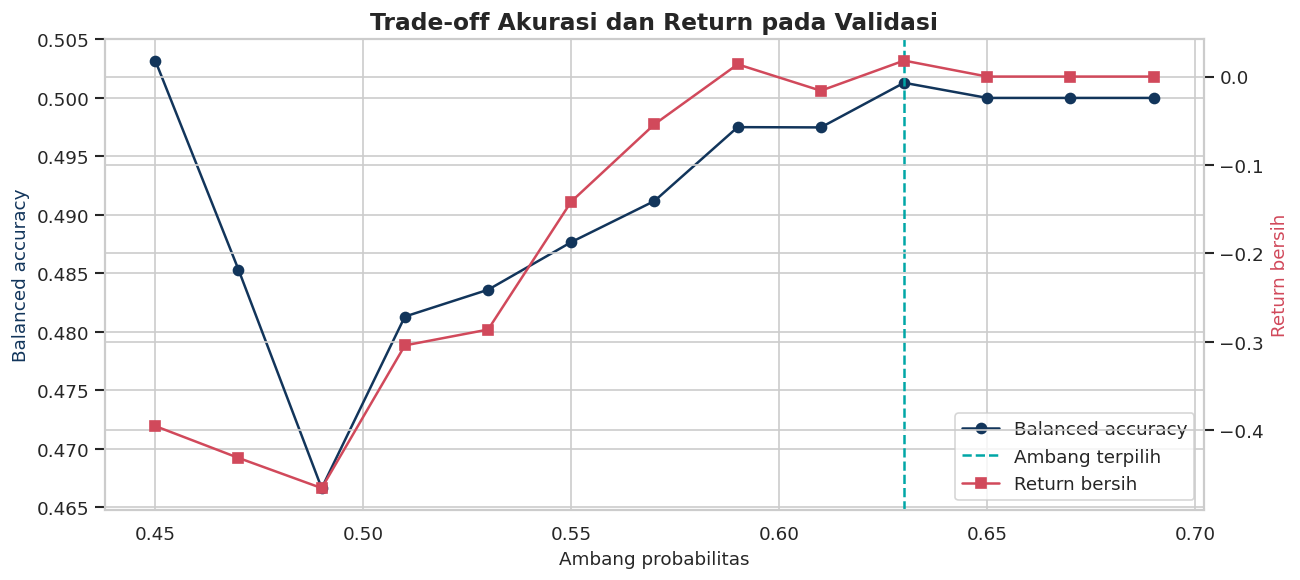

In [12]:
def strategy_statistics(
    probabilities,
    actual_direction,
    execution_log_return,
    threshold,
    cost_bps,
):
    position = (np.asarray(probabilities) >= threshold).astype(int)
    turnover = np.abs(np.diff(position, prepend=0))
    gross = position * np.asarray(execution_log_return)
    net = gross - (cost_bps / 10_000) * turnover
    positive = net[net > 0].sum()
    negative = abs(net[net < 0].sum())
    profit_factor = positive / negative if negative > 0 else np.nan
    return {
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(actual_direction, position),
        "f1": f1_score(actual_direction, position, zero_division=0),
        "net_return": np.exp(net.sum()) - 1,
        "profit_factor": profit_factor,
        "trades": int(turnover.sum()),
        "position": position,
        "net_series": net,
    }


trader_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                C=0.5,
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
trader_pipeline.fit(trader_train[FEATURE_COLUMNS], trader_train["direction_next"])
val_probability = trader_pipeline.predict_proba(trader_val[FEATURE_COLUMNS])[:, 1]

threshold_rows = []
for threshold in np.arange(0.45, 0.71, 0.02):
    stats = strategy_statistics(
        val_probability,
        trader_val["direction_next"].values,
        trader_val["exec_return_next"].values,
        float(threshold),
        TRADING_COST_BPS,
    )
    threshold_rows.append(
        {
            "Ambang": stats["threshold"],
            "Balanced accuracy": stats["balanced_accuracy"],
            "F1": stats["f1"],
            "Return bersih": stats["net_return"],
            "Profit factor": stats["profit_factor"],
            "Jumlah transaksi": stats["trades"],
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table[threshold_table["Balanced accuracy"] >= 0.50]
if eligible.empty:
    best_threshold = float(
        threshold_table.sort_values("Balanced accuracy", ascending=False).iloc[0]["Ambang"]
    )
else:
    best_threshold = float(
        eligible.sort_values(
            ["Return bersih", "Balanced accuracy"], ascending=False
        ).iloc[0]["Ambang"]
    )

display(Markdown("### Output Tahap 10: Seleksi Ambang Trader"))
display(threshold_table)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(
    threshold_table["Ambang"],
    threshold_table["Balanced accuracy"],
    marker="o",
    color="#12355B",
    label="Balanced accuracy",
)
ax1.set_ylabel("Balanced accuracy", color="#12355B")
ax1.set_xlabel("Ambang probabilitas")
ax2 = ax1.twinx()
ax2.plot(
    threshold_table["Ambang"],
    threshold_table["Return bersih"],
    marker="s",
    color="#D1495B",
    label="Return bersih",
)
ax2.set_ylabel("Return bersih", color="#D1495B")
ax1.axvline(best_threshold, color="#00A6A6", linestyle="--", label="Ambang terpilih")
ax1.set_title("Trade-off Akurasi dan Return pada Validasi")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="best")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_ambang_trader.png", bbox_inches="tight")
plt.show()



### Output Tahap 11: Evaluasi Trader Harian

,Aturan,Nilai
0,Informasi terakhir,Penutupan hari t
1,Waktu eksekusi,Pembukaan hari t+1
2,Target,Arah Open-to-Close hari t+1
3,Biaya per perubahan posisi,10 bps
4,Ambang terpilih,0.63


,Strategi,Balanced accuracy,F1,Return bersih,Profit factor,Transaksi
0,Model arah,0.5000,0.0000,0.0000,NaN,0
1,Selalu long,0.5000,0.6429,-0.6028,0.7017,1


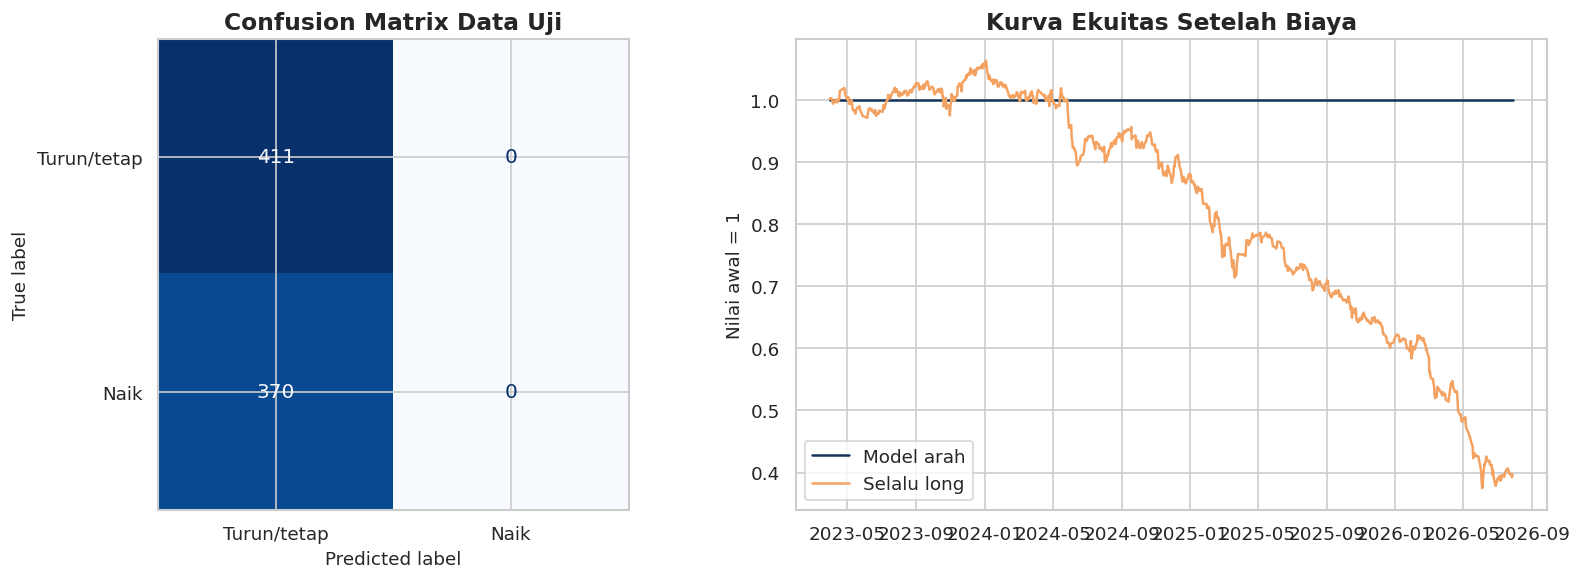

In [13]:
trader_fit = pd.concat([trader_train, trader_val]).sort_index()
final_trader_model = clone(trader_pipeline)
final_trader_model.fit(trader_fit[FEATURE_COLUMNS], trader_fit["direction_next"])
test_probability = final_trader_model.predict_proba(trader_test[FEATURE_COLUMNS])[:, 1]

trader_stats = strategy_statistics(
    test_probability,
    trader_test["direction_next"].values,
    trader_test["exec_return_next"].values,
    best_threshold,
    TRADING_COST_BPS,
)

always_long_prob = np.ones(len(trader_test))
always_long = strategy_statistics(
    always_long_prob,
    trader_test["direction_next"].values,
    trader_test["exec_return_next"].values,
    0.5,
    TRADING_COST_BPS,
)

trader_metrics = pd.DataFrame(
    {
        "Strategi": ["Model arah", "Selalu long"],
        "Balanced accuracy": [
            trader_stats["balanced_accuracy"],
            always_long["balanced_accuracy"],
        ],
        "F1": [trader_stats["f1"], always_long["f1"]],
        "Return bersih": [trader_stats["net_return"], always_long["net_return"]],
        "Profit factor": [
            trader_stats["profit_factor"],
            always_long["profit_factor"],
        ],
        "Transaksi": [trader_stats["trades"], always_long["trades"]],
    }
)

display(Markdown("### Output Tahap 11: Evaluasi Trader Harian"))
display(
    pd.DataFrame(
        {
            "Aturan": [
                "Informasi terakhir",
                "Waktu eksekusi",
                "Target",
                "Biaya per perubahan posisi",
                "Ambang terpilih",
            ],
            "Nilai": [
                "Penutupan hari t",
                "Pembukaan hari t+1",
                "Arah Open-to-Close hari t+1",
                f"{TRADING_COST_BPS} bps",
                f"{best_threshold:.2f}",
            ],
        }
    )
)
display(trader_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(
    confusion_matrix(
        trader_test["direction_next"],
        trader_stats["position"],
        labels=[0, 1],
    ),
    display_labels=["Turun/tetap", "Naik"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix Data Uji")

model_equity = np.exp(np.cumsum(trader_stats["net_series"]))
long_equity = np.exp(np.cumsum(always_long["net_series"]))
axes[1].plot(trader_test.index, model_equity, color="#12355B", label="Model arah")
axes[1].plot(trader_test.index, long_equity, color="#F4A261", label="Selalu long")
axes[1].set_title("Kurva Ekuitas Setelah Biaya")
axes[1].set_ylabel("Nilai awal = 1")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_hasil_trader.png", bbox_inches="tight")
plt.show()



**Analisis Kritis Model Trader**

Ambang probabilitas dipilih pada validasi, bukan data uji. Strategi hanya
mengambil posisi ketika probabilitas melewati ambang tersebut. Balanced
accuracy mencegah model terlihat baik hanya karena memilih kelas dominan.
Return bersih menguji manfaat ekonomi setelah biaya. Profit factor di bawah
satu berarti total kerugian lebih besar daripada total keuntungan. Akurasi yang
tinggi tetap dapat gagal menghasilkan keuntungan jika model benar pada
perubahan kecil tetapi salah pada pergerakan besar.



## E. Model 3: Manajer Dana Pensiun

Baseline memakai target return kumulatif 12 bulan. Horizon dapat diperpanjang
menjadi 36 atau 60 bulan, tetapi jumlah periode independen akan berkurang tajam.
OHLCV dan indikator teknikal saja juga tidak cukup untuk keputusan dana pensiun
produksi. Variabel kewajiban, arus kas, inflasi, suku bunga, komposisi aset, dan
kovarians aset perlu ditambahkan pada penelitian lanjutan.



### Output Tahap 12: Kelayakan Horizon Dana Pensiun

,Horizon,Target bulanan tersedia,Perkiraan periode non-overlap,Status baseline
0,1 tahun,246,20,Dimodelkan
1,3 tahun,222,6,"Analisis sensitivitas, interpretasi hati-hati"
2,5 tahun,198,3,"Analisis sensitivitas, interpretasi hati-hati"


,Klien,Bagian,Awal,Akhir,Observasi,Purge gap
0,Manajer dana pensiun,Latih,2005-02-28,2018-05-31,160,12
1,Manajer dana pensiun,Validasi,2019-06-30,2021-06-30,25,12
2,Manajer dana pensiun,Uji,2022-07-31,2025-07-31,37,12


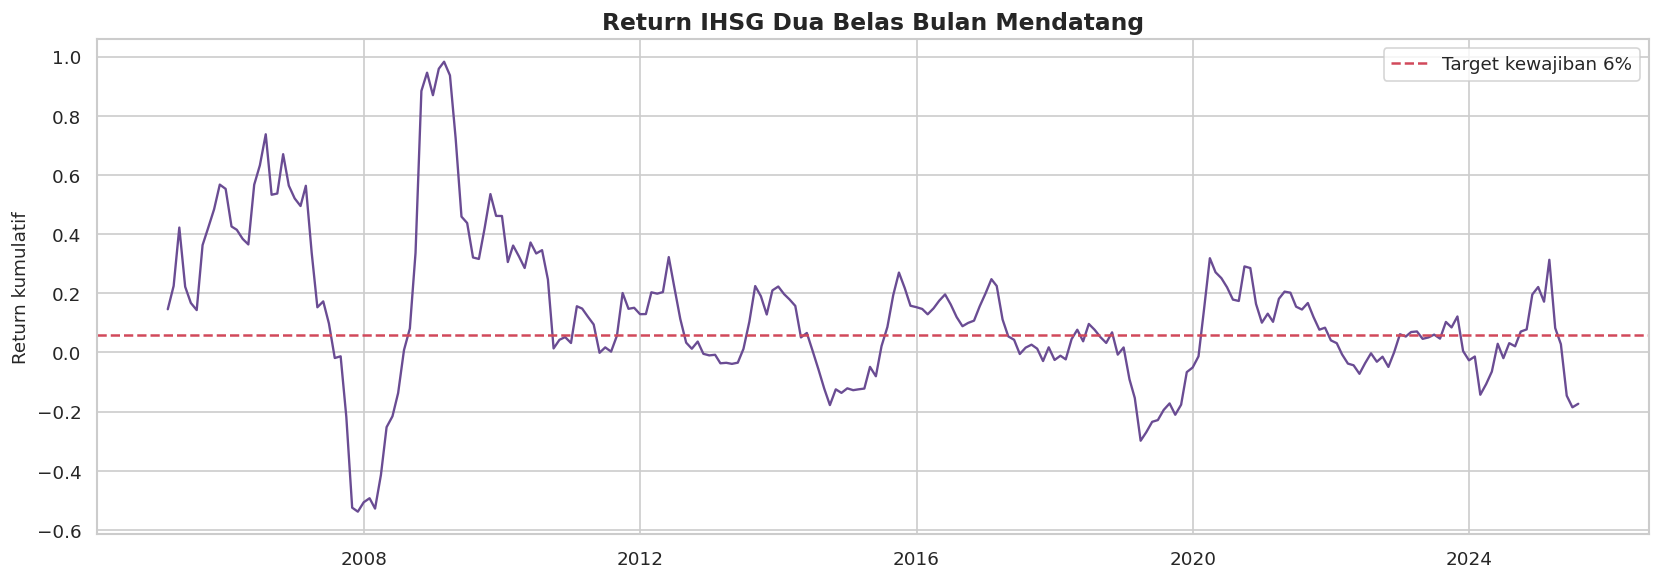

In [14]:
monthly_features = model_base[FEATURE_COLUMNS].resample("M").last()
monthly_close = model_base["Close"].resample("M").last()
monthly_log_return = np.log(monthly_close / monthly_close.shift(1))

pension_data = monthly_features.copy()
pension_data["monthly_log_return"] = monthly_log_return
pension_data["return_target_h"] = future_rolling(
    monthly_log_return, PENSION_HORIZON_MONTHS, "sum"
)
pension_data["next_month_return"] = monthly_log_return.shift(-1)
pension_data = pension_data.dropna(
    subset=FEATURE_COLUMNS + ["return_target_h", "next_month_return"]
)

pension_train, pension_val, pension_test = purged_chronological_split(
    pension_data, gap=PENSION_HORIZON_MONTHS, min_size=18
)

feasibility_rows = []
for years in [1, 3, 5]:
    months = years * 12
    available_targets = int(
        future_rolling(monthly_log_return, months, "sum").notna().sum()
    )
    approx_independent = available_targets // months
    feasibility_rows.append(
        {
            "Horizon": f"{years} tahun",
            "Target bulanan tersedia": available_targets,
            "Perkiraan periode non-overlap": approx_independent,
            "Status baseline": (
                "Dimodelkan"
                if months == PENSION_HORIZON_MONTHS
                else "Analisis sensitivitas, interpretasi hati-hati"
            ),
        }
    )

display(Markdown("### Output Tahap 12: Kelayakan Horizon Dana Pensiun"))
display(pd.DataFrame(feasibility_rows))
display(
    split_summary(
        "Manajer dana pensiun",
        pension_train,
        pension_val,
        pension_test,
        PENSION_HORIZON_MONTHS,
    )
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    pension_data.index,
    np.expm1(pension_data["return_target_h"]),
    color="#6A4C93",
    linewidth=1.4,
)
ax.axhline(
    LIABILITY_TARGET_ANNUAL,
    color="#D1495B",
    linestyle="--",
    label=f"Target kewajiban {LIABILITY_TARGET_ANNUAL:.0%}",
)
ax.set_title("Return IHSG Dua Belas Bulan Mendatang")
ax.set_ylabel("Return kumulatif")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_target_pensiun.png", bbox_inches="tight")
plt.show()



In [15]:
ridge_alphas = [0.1, 1.0, 10.0, 100.0]
pension_validation_rows = []

for alpha in ridge_alphas:
    pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha)),
        ]
    )
    pipeline.fit(pension_train[FEATURE_COLUMNS], pension_train["return_target_h"])
    pred = pipeline.predict(pension_val[FEATURE_COLUMNS])
    pension_validation_rows.append(
        {
            "Alpha": alpha,
            "MAE return 12 bulan": mean_absolute_error(
                pension_val["return_target_h"], pred
            ),
        }
    )

pension_validation = pd.DataFrame(pension_validation_rows).sort_values(
    "MAE return 12 bulan"
)
best_alpha = float(pension_validation.iloc[0]["Alpha"])

display(Markdown("### Output Tahap 13: Seleksi Model Dana Pensiun"))
display(pension_validation)



### Output Tahap 13: Seleksi Model Dana Pensiun

,Alpha,MAE return 12 bulan
3,100.0000,0.1245
2,10.0000,0.1356
1,1.0000,0.1446
0,0.1000,0.1573


### Output Tahap 14: Evaluasi Dana Pensiun

,Strategi,Return tahunan,Volatilitas tahunan,Sharpe,Maximum drawdown,Pencapaian kewajiban,MAE prediksi 12 bulan
0,Alokasi berbasis model,0.0096,0.1155,-0.2571,0.1697,0.2308,0.1009
1,IHSG buy-and-hold,0.0394,0.1304,-0.0045,0.1825,0.2692,NaN


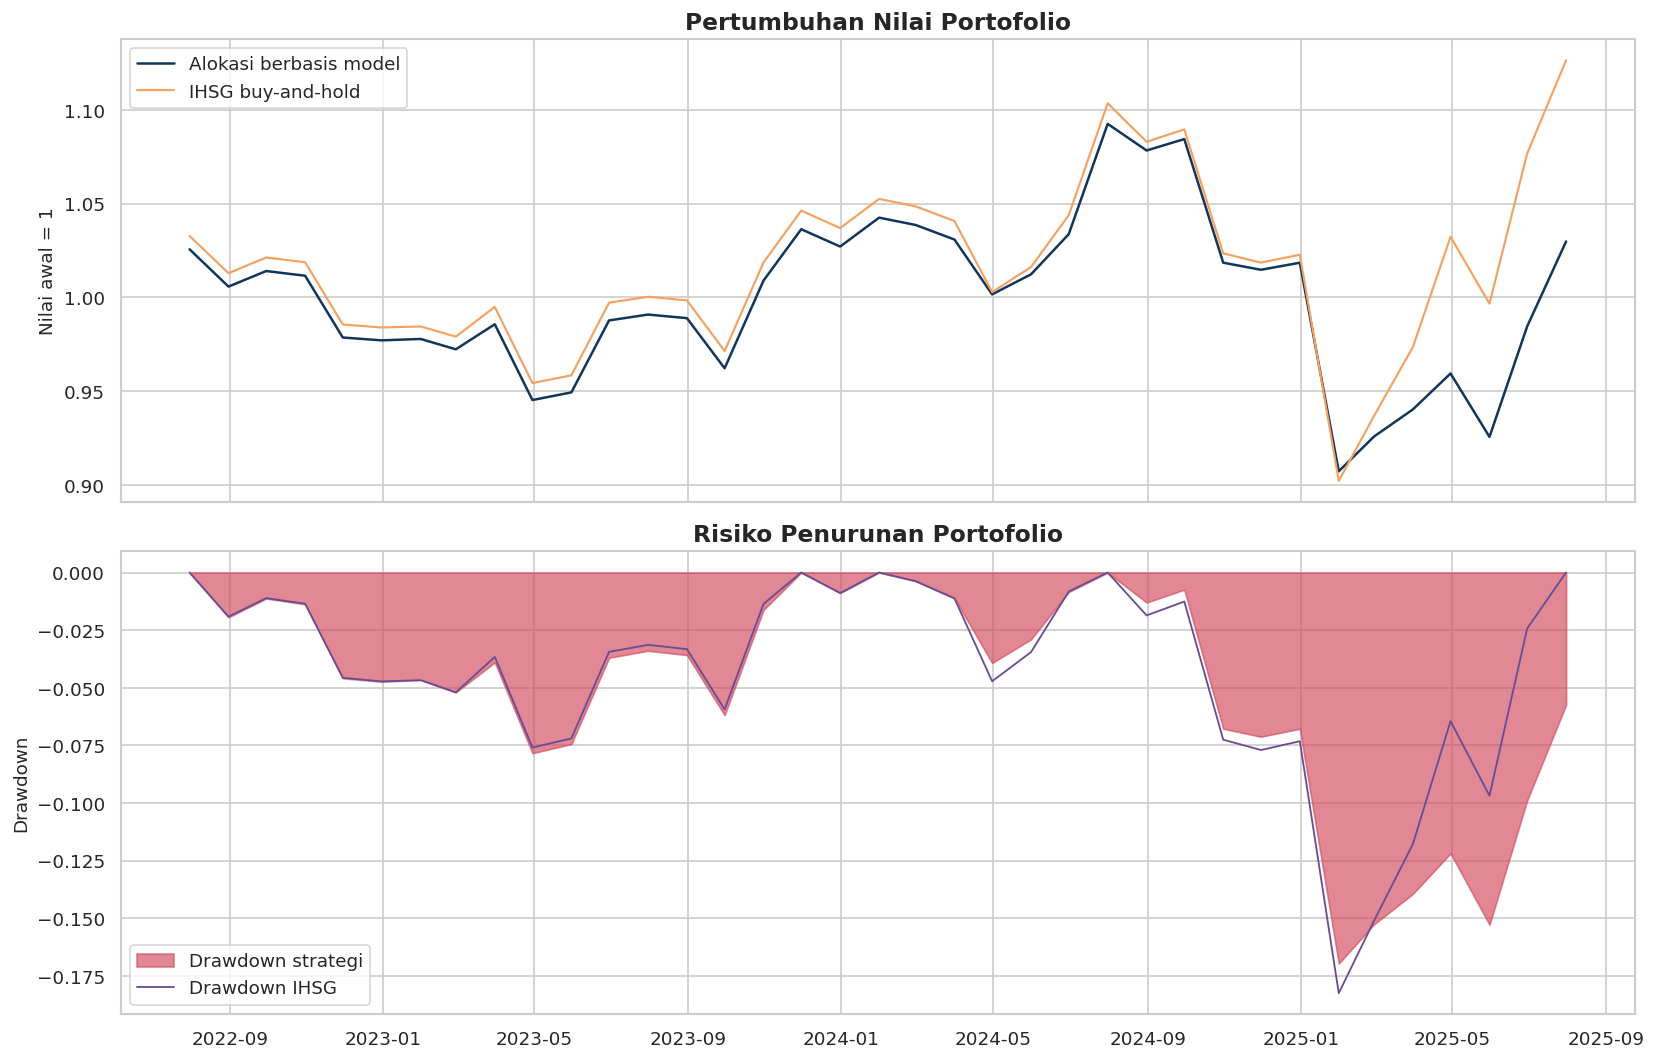

In [16]:
pension_fit = pd.concat([pension_train, pension_val]).sort_index()
pension_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha)),
    ]
)
pension_model.fit(pension_fit[FEATURE_COLUMNS], pension_fit["return_target_h"])
pension_pred = pension_model.predict(pension_test[FEATURE_COLUMNS])

rf_month_log = np.log1p(RISK_FREE_ANNUAL) / 12
liability_log = np.log1p(LIABILITY_TARGET_ANNUAL)

# Skor alokasi berbasis target return, lalu dibatasi oleh volatilitas.
base_weight = np.where(
    pension_pred >= liability_log,
    1.0,
    np.where(pension_pred >= np.log1p(RISK_FREE_ANNUAL), 0.60, 0.20),
)
current_vol = pension_test["volatility_20"].clip(lower=0.01).values
risk_cap = np.clip(0.12 / current_vol, 0.20, 1.0)
pension_weight = np.minimum(base_weight, risk_cap)

pension_turnover = np.abs(np.diff(pension_weight, prepend=0.0))
pension_net_log = (
    pension_weight * pension_test["next_month_return"].values
    + (1 - pension_weight) * rf_month_log
    - (TRADING_COST_BPS / 10_000) * pension_turnover
)
benchmark_log = pension_test["next_month_return"].values.copy()


def portfolio_metrics(log_returns, annual_liability):
    values = np.exp(np.cumsum(log_returns))
    years = len(log_returns) / 12
    annual_return = values[-1] ** (1 / years) - 1 if years > 0 else np.nan
    monthly_excess = log_returns - np.log1p(RISK_FREE_ANNUAL) / 12
    sharpe = (
        monthly_excess.mean() / monthly_excess.std(ddof=1) * np.sqrt(12)
        if monthly_excess.std(ddof=1) > 0
        else np.nan
    )
    running_peak = np.maximum.accumulate(values)
    drawdown = values / running_peak - 1
    annual_rolling = (
        pd.Series(log_returns)
        .rolling(12)
        .sum()
        .dropna()
    )
    liability_hit = (
        (annual_rolling >= np.log1p(annual_liability)).mean()
        if len(annual_rolling)
        else np.nan
    )
    return {
        "annual_return": annual_return,
        "annual_volatility": np.std(log_returns, ddof=1) * np.sqrt(12),
        "sharpe": sharpe,
        "maximum_drawdown": abs(drawdown.min()),
        "liability_hit": liability_hit,
        "values": values,
        "drawdown_series": drawdown,
    }


pension_stats = portfolio_metrics(pension_net_log, LIABILITY_TARGET_ANNUAL)
benchmark_stats = portfolio_metrics(benchmark_log, LIABILITY_TARGET_ANNUAL)

pension_metrics = pd.DataFrame(
    {
        "Strategi": ["Alokasi berbasis model", "IHSG buy-and-hold"],
        "Return tahunan": [
            pension_stats["annual_return"],
            benchmark_stats["annual_return"],
        ],
        "Volatilitas tahunan": [
            pension_stats["annual_volatility"],
            benchmark_stats["annual_volatility"],
        ],
        "Sharpe": [pension_stats["sharpe"], benchmark_stats["sharpe"]],
        "Maximum drawdown": [
            pension_stats["maximum_drawdown"],
            benchmark_stats["maximum_drawdown"],
        ],
        "Pencapaian kewajiban": [
            pension_stats["liability_hit"],
            benchmark_stats["liability_hit"],
        ],
        "MAE prediksi 12 bulan": [
            mean_absolute_error(pension_test["return_target_h"], pension_pred),
            np.nan,
        ],
    }
)

display(Markdown("### Output Tahap 14: Evaluasi Dana Pensiun"))
display(pension_metrics)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(
    pension_test.index,
    pension_stats["values"],
    color="#12355B",
    linewidth=1.5,
    label="Alokasi berbasis model",
)
axes[0].plot(
    pension_test.index,
    benchmark_stats["values"],
    color="#F4A261",
    linewidth=1.3,
    label="IHSG buy-and-hold",
)
axes[0].set_title("Pertumbuhan Nilai Portofolio")
axes[0].set_ylabel("Nilai awal = 1")
axes[0].legend()

axes[1].fill_between(
    pension_test.index,
    pension_stats["drawdown_series"],
    0,
    color="#D1495B",
    alpha=0.65,
    label="Drawdown strategi",
)
axes[1].plot(
    pension_test.index,
    benchmark_stats["drawdown_series"],
    color="#6A4C93",
    linewidth=1.1,
    label="Drawdown IHSG",
)
axes[1].set_title("Risiko Penurunan Portofolio")
axes[1].set_ylabel("Drawdown")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_hasil_pensiun.png", bbox_inches="tight")
plt.show()



**Analisis Kritis Model Dana Pensiun**

MAE return 12 bulan hanya mengukur kesalahan prediksi. Manajer dana pensiun
lebih membutuhkan kemampuan memenuhi kewajiban dengan risiko yang dapat
diterima. Karena itu, hasil portofolio dinilai melalui return tahunan,
volatilitas, Sharpe, maximum drawdown, dan proporsi periode 12 bulan yang
melampaui target kewajiban. Jika strategi menghasilkan return lebih tinggi
tetapi drawdown jauh lebih besar, keputusan belum tentu sesuai dengan mandat
dana pensiun.



## F. Audit Bug, Kebocoran Data, dan Logika



In [17]:
def chronological_ok(train, validation, test):
    return train.index.max() < validation.index.min() < test.index.min()


checks = [
    {
        "Pemeriksaan": "Indeks tanggal terurut",
        "Lulus": bool(df.index.is_monotonic_increasing),
        "Risiko jika gagal": "Urutan masa lalu dan masa depan tercampur",
    },
    {
        "Pemeriksaan": "Tidak ada tanggal duplikat",
        "Lulus": bool(df.index.duplicated().sum() == 0),
        "Risiko jika gagal": "Observasi tertentu mendapat bobot ganda",
    },
    {
        "Pemeriksaan": "OHLC konsisten",
        "Lulus": bool(not invalid_ohlc.any()),
        "Risiko jika gagal": "Return dan indikator berasal dari harga salah",
    },
    {
        "Pemeriksaan": "Jumlah fitur tepat 15",
        "Lulus": bool(len(FEATURE_COLUMNS) == 15),
        "Risiko jika gagal": "Eksperimen tidak sesuai desain",
    },
    {
        "Pemeriksaan": "Fitur bebas target",
        "Lulus": bool(
            not any(
                c in FEATURE_COLUMNS
                for c in [
                    "risk_target_vol",
                    "future_log_return_h",
                    "direction_next",
                    "exec_return_next",
                    "return_target_h",
                ]
            )
        ),
        "Risiko jika gagal": "Target leakage",
    },
    {
        "Pemeriksaan": "Split risiko kronologis",
        "Lulus": bool(chronological_ok(risk_train, risk_val, risk_test)),
        "Risiko jika gagal": "Hasil risiko terlalu optimistis",
    },
    {
        "Pemeriksaan": "Split trader kronologis",
        "Lulus": bool(chronological_ok(trader_train, trader_val, trader_test)),
        "Risiko jika gagal": "Backtest tidak menyerupai perdagangan nyata",
    },
    {
        "Pemeriksaan": "Execution lag trader aktif",
        "Lulus": bool(
            np.allclose(
                trader_data["exec_return_next"].values,
                np.log(
                    model_base["Close"].shift(-1)
                    / model_base["Open"].shift(-1)
                )
                .reindex(trader_data.index)
                .values,
                equal_nan=True,
            )
        ),
        "Risiko jika gagal": "Transaksi memakai harga yang sudah berlalu",
    },
    {
        "Pemeriksaan": "Biaya transaksi positif",
        "Lulus": bool(TRADING_COST_BPS > 0),
        "Risiko jika gagal": "Return bersih dibesar-besarkan",
    },
    {
        "Pemeriksaan": "Split dana pensiun kronologis",
        "Lulus": bool(chronological_ok(pension_train, pension_val, pension_test)),
        "Risiko jika gagal": "Kinerja jangka panjang bias",
    },
]

audit_table = pd.DataFrame(checks)
display(Markdown("### Output Tahap 15: Audit Logika Program"))
display(audit_table)

if not audit_table["Lulus"].all():
    failed = audit_table.loc[~audit_table["Lulus"], "Pemeriksaan"].tolist()
    raise AssertionError(f"Audit gagal pada: {failed}")



### Output Tahap 15: Audit Logika Program

,Pemeriksaan,Lulus,Risiko jika gagal
0,Indeks tanggal terurut,True,Urutan masa lalu dan masa depan tercampur
1,Tidak ada tanggal duplikat,True,Observasi tertentu mendapat bobot ganda
2,OHLC konsisten,True,Return dan indikator berasal dari harga salah
3,Jumlah fitur tepat 15,True,Eksperimen tidak sesuai desain
4,Fitur bebas target,True,Target leakage
5,Split risiko kronologis,True,Hasil risiko terlalu optimistis
6,Split trader kronologis,True,Backtest tidak menyerupai perdagangan nyata
7,Execution lag trader aktif,True,Transaksi memakai harga yang sudah berlalu
8,Biaya transaksi positif,True,Return bersih dibesar-besarkan
9,Split dana pensiun kronologis,True,Kinerja jangka panjang bias


**Interpretasi Audit**

Audit memeriksa kesalahan yang sering membuat hasil keuangan tampak terlalu
baik. Pemeriksaan terpenting adalah pemisahan target dari fitur, urutan split,
*purge gap*, execution lag, dan biaya transaksi. Audit tidak membuktikan bahwa
model benar secara ekonomi. Audit hanya memastikan bahwa implementasi mengikuti
rumusan masalah dan tidak mengandung kesalahan logika utama yang telah
didefinisikan.



## G. Perbandingan Tiga Rumusan Masalah



In [18]:
comparison_matrix = pd.DataFrame(
    {
        "Klien": [
            "Analis risiko",
            "Trader harian",
            "Manajer dana pensiun",
        ],
        "Target": [
            "Volatilitas dan potensi kerugian",
            "Arah return yang dapat dieksekusi",
            "Return kumulatif dan risiko portofolio",
        ],
        "Horizon": [
            f"{RISK_HORIZON_DAYS} hari perdagangan",
            "1 hari perdagangan",
            f"{PENSION_HORIZON_MONTHS} bulan, baseline 1 tahun",
        ],
        "Model baseline": [
            "HistGradientBoostingRegressor",
            "LogisticRegression",
            "Ridge",
        ],
        "Metrik utama": [
            "MAE volatilitas, cakupan VaR, recall lonjakan",
            "Balanced accuracy, F1, return bersih, profit factor",
            "Return tahunan, Sharpe, drawdown, pencapaian kewajiban",
        ],
        "Keputusan": [
            "Mengurangi atau melindungi eksposur",
            "Beli atau tetap tunai pada sesi berikutnya",
            "Menetapkan bobot aset berisiko dan aset bebas risiko",
        ],
    }
)

critical_analysis = pd.DataFrame(
    {
        "Temuan kritis": [
            "Satu dataset tidak berarti satu target",
            "Akurasi statistik tidak identik dengan manfaat ekonomi",
            "Horizon panjang mengurangi informasi efektif",
            "Volume indeks dapat tidak andal",
            "Perubahan rezim pasar tetap menjadi risiko",
        ],
        "Dasar logis": [
            "Setiap klien mengambil keputusan berbeda",
            "Biaya, ukuran perubahan, dan drawdown memengaruhi hasil",
            "Target 3 sampai 5 tahun saling tumpang tindih dan sampelnya terbatas",
            "MFI kehilangan makna jika volume nol atau hasil konstruksi penyedia",
            "Hubungan indikator dan return dapat berubah setelah krisis atau kebijakan baru",
        ],
        "Implikasi": [
            "Pisahkan target, horizon, dan metrik",
            "Gunakan backtest setelah biaya dan execution lag",
            "Batasi klaim dana pensiun dan tambahkan data fundamental",
            "Audit sumber volume atau ganti dengan data resmi",
            "Lakukan walk-forward monitoring dan retraining",
        ],
    }
)

display(Markdown("### Output Tahap 16: Matriks Perbandingan"))
display(comparison_matrix)
display(Markdown("### Analisis Kritis"))
display(critical_analysis)



### Output Tahap 16: Matriks Perbandingan

,Klien,Target,Horizon,Model baseline,Metrik utama,Keputusan
0,Analis risiko,Volatilitas dan potensi kerugian,10 hari perdagangan,HistGradientBoostingRegressor,"MAE volatilitas, cakupan VaR, recall lonjakan",Mengurangi atau melindungi eksposur
1,Trader harian,Arah return yang dapat dieksekusi,1 hari perdagangan,LogisticRegression,"Balanced accuracy, F1, return bersih, profit f...",Beli atau tetap tunai pada sesi berikutnya
2,Manajer dana pensiun,Return kumulatif dan risiko portofolio,"12 bulan, baseline 1 tahun",Ridge,"Return tahunan, Sharpe, drawdown, pencapaian k...",Menetapkan bobot aset berisiko dan aset bebas ...


### Analisis Kritis

,Temuan kritis,Dasar logis,Implikasi
0,Satu dataset tidak berarti satu target,Setiap klien mengambil keputusan berbeda,"Pisahkan target, horizon, dan metrik"
1,Akurasi statistik tidak identik dengan manfaat...,"Biaya, ukuran perubahan, dan drawdown memengar...",Gunakan backtest setelah biaya dan execution lag
2,Horizon panjang mengurangi informasi efektif,Target 3 sampai 5 tahun saling tumpang tindih ...,Batasi klaim dana pensiun dan tambahkan data f...
3,Volume indeks dapat tidak andal,MFI kehilangan makna jika volume nol atau hasi...,Audit sumber volume atau ganti dengan data resmi
4,Perubahan rezim pasar tetap menjadi risiko,Hubungan indikator dan return dapat berubah se...,Lakukan walk-forward monitoring dan retraining


In [19]:
summary_metrics = pd.DataFrame(
    {
        "Klien": ["Analis risiko", "Trader harian", "Manajer dana pensiun"],
        "Indikator 1": [
            f"MAE vol = {risk_metrics.iloc[0]['MAE volatilitas']:.4f}",
            f"Balanced accuracy = {trader_stats['balanced_accuracy']:.4f}",
            f"Return tahunan = {pension_stats['annual_return']:.2%}",
        ],
        "Indikator 2": [
            f"Pelanggaran VaR = {risk_metrics.iloc[0]['Pelanggaran VaR (%)']:.2f}%",
            f"F1 = {trader_stats['f1']:.4f}",
            f"Sharpe = {pension_stats['sharpe']:.4f}",
        ],
        "Indikator 3": [
            f"Recall lonjakan = {spike_recall:.4f}",
            f"Return bersih = {trader_stats['net_return']:.2%}",
            f"Maximum drawdown = {pension_stats['maximum_drawdown']:.2%}",
        ],
    }
)

display(Markdown("### Output Tahap 17: Ringkasan Hasil Uji"))
display(summary_metrics)

# Simpan keluaran utama.
exports = {
    "kualitas_data.csv": quality,
    "fitur_teknikal_terakhir.csv": feature_dictionary,
    "hasil_analis_risiko.csv": risk_metrics,
    "hasil_trader_harian.csv": trader_metrics,
    "hasil_dana_pensiun.csv": pension_metrics,
    "matriks_perbandingan.csv": comparison_matrix,
    "audit_logika.csv": audit_table,
}

for filename, table in exports.items():
    table.to_csv(OUTPUT_DIR / filename, index=False)

export_table = pd.DataFrame(
    {
        "File": list(exports.keys()),
        "Lokasi": [str(OUTPUT_DIR / name) for name in exports],
    }
)
display(Markdown("### Output Tahap 18: File Hasil"))
display(export_table)



### Output Tahap 17: Ringkasan Hasil Uji

,Klien,Indikator 1,Indikator 2,Indikator 3
0,Analis risiko,MAE vol = 0.0519,Pelanggaran VaR = 8.99%,Recall lonjakan = 0.3291
1,Trader harian,Balanced accuracy = 0.5000,F1 = 0.0000,Return bersih = 0.00%
2,Manajer dana pensiun,Return tahunan = 0.96%,Sharpe = -0.2571,Maximum drawdown = 16.97%


### Output Tahap 18: File Hasil

,File,Lokasi
0,kualitas_data.csv,/kaggle/working/kualitas_data.csv
1,fitur_teknikal_terakhir.csv,/kaggle/working/fitur_teknikal_terakhir.csv
2,hasil_analis_risiko.csv,/kaggle/working/hasil_analis_risiko.csv
3,hasil_trader_harian.csv,/kaggle/working/hasil_trader_harian.csv
4,hasil_dana_pensiun.csv,/kaggle/working/hasil_dana_pensiun.csv
5,matriks_perbandingan.csv,/kaggle/working/matriks_perbandingan.csv
6,audit_logika.csv,/kaggle/working/audit_logika.csv


## H. Kesimpulan Logis

Dataset OHLCV dan indikator teknikal yang sama tidak membenarkan penggunaan
satu model untuk seluruh pengguna. Analis risiko memerlukan prediksi distribusi
kerugian dan sensitivitas terhadap lonjakan. Trader harian memerlukan sinyal
yang dapat dieksekusi setelah mempertimbangkan jeda dan biaya. Manajer dana
pensiun memerlukan pertumbuhan jangka panjang yang konsisten dengan kewajiban
dan batas drawdown.

Hasil model harus dibandingkan dengan baseline sederhana. Model kompleks tidak
layak dipilih jika gagal mengungguli volatilitas bergulir, strategi selalu
membeli, atau buy-and-hold setelah biaya. Untuk penggunaan produksi, tambahkan
validasi walk-forward, uji stabilitas rezim, data resmi BEI, faktor makro,
komposisi portofolio, struktur kewajiban, serta skenario stres. Klaim penelitian
hanya berlaku pada ticker, periode, sumber data, biaya, horizon, dan aturan
eksekusi yang benar-benar diuji.
